- datasets 라이브러리로부터 허깅페이스의 데이터를 다운로드 하는데 사용할 load_dataset을 임포트합니다.


In [1]:
from datasets import load_dataset

dataset = load_dataset("iamjoon/klue-mrc-ko-rag-dataset")

c:\workspace\python\rag_master\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- 허깅페이스로부터 데이터를 로드하고 이를 출력해보겠습니다.
- 로드된 데이터셋을 판다스 데이터프레임으로 변환합니다.
- 판다스로 변환한 이유는 데이터 조작과 분석을 보다 쉽게 하기 위함입니다.
- 실습에 필요한 열만 선택하여 새로운 데이터프레임을 만듭니다.


In [2]:
df = dataset["train"].to_pandas()
df = df[["question", "search_result", "answer", "extracted_ref_numbers", "type"]]
df.head()

,question,search_result,answer,extracted_ref_numbers,type
0,북태평양 기단과 오호츠크해 기단이 만나 국내에 머무르는 기간은?,[열대우림 '장마전선'은 벵골만과 서북태평양에서 동아시아 몬순의 하위시스템으로 조성...,북태평양 기단과 오호츠크해 기단이 만나 형성되는 장마전선은 한반도에 약 한 달가량 ...,[2],mrc_question
1,지능형 생산자동화 기반기술을 개발중인 스타트업은?,[부산시와 (재)부산정보산업진흥원(원장 이인숙)이 ‘2020~2021년 지역SW서비...,지능형 생산자동화 기반기술을 개발 중인 스타트업으로는 삼보테크놀로지가 있습니다. 삼...,[1],mrc_question
2,개막전에서 3안타 2실점을 기록해서 패한 선수는?,"[;한큐 - 사카모토 도시조\n* 타석에서의 상황 : 헛스윙, 볼, 헛스윙, 파울,...",개막전에서 3안타 2실점을 기록해서 패한 선수는 사이타마 세이부 라이온스의 와쿠이 ...,[2],mrc_question
3,컵라면 매출에서 불닭볶음면을 이긴 상품은?,[유명 맛집 이름을 달고 나온 편의점 자체상표(PB) 라면이 인기를 끌고 있다. ‘...,세븐일레븐에서 판매하는 '교동반점 짬뽕'이 삼양식품의 '불닭볶음면'을 제치고 컵라면...,[1],mrc_question
4,정부에게 환경과 관련해서 우선적으로 원조 받고 있는 곳은?,[정부가 전기자동차를 보급하는 방식을 바꾼다. 주로 일반 소비자와 관공서에 판매하던...,정부가 환경과 관련하여 우선적으로 원조를 받고 있는 곳은 주로 전기자동차 보급과 관...,[1],mrc_question


- question(질문), search_result(질문에 대한 검색 결과), answer(최종답변), extracted_ref_numers(답변에서 인용된 문서 번호의 리스트), type(데이터 유형)입니다.


In [3]:
print("데이터 타입 종류:", df["type"].unique())

데이터 타입 종류: ['mrc_question' 'mrc_question_with_1_to_4_negative' 'synthetic_question'
 'paraphrased_question' 'no_answer']


| type                              | 내용                                                                                                                                                                                                                                         |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| mrc_question                      | 장소나 이름, 날짜 등을 묻는 지엽적인 질문<br/>검색 결과(search_result)는 5개로 고정                                                                                                                                                          |
| mrc_question_with_1_to_4_negative | 장소나 이름, 날짜 등을 묻는 지엽적인 질문<br/>검색 결과(search_result)가 1~4개 사이인 유형                                                                                                                                                   |
| paraphrased_question              | 장소나 이름, 날짜 등을 묻는 지엽적인 질문이며 질문의 형태가 문장이 아닌 명사구의 형태<br/>검색 결과(search_result)는 5개로 고정                                                                                                              |
| synthetic_question                | 이유, 장점, 단점 등과 같은 포괄적인 질문<br/>검색 결과(search_result)는 5개로 고정<br/>포괄적인 질문이므로 일반적으로 다수의 문서를 인용하게 된다는 특징이 있음.<br/>따라서 일반적으로 인용 문서 번호(extracted_ref_numbers)의 값이 2개 이상 |
| no_answer                         | 질문에 대한 답이 검색 결과에 없는 데이터<br/>답변(answer)에는 검색 결과에 질문에 대한 답이 없다고 안내해야만 함<br />검색 결과(search_result)는 5개로 고정                                                                                   |


- 각 데이터 유형은 실제 검색 증강 생성에서 발생할 수 있는 다양한 시나리오에 대응하기 위한 목적으로 만들어졌습니다.
- 학습 후에 실제 상황에서 질문에 대한 답이 데이터에 없는 경우가 발생하면 성능이 저하되는 경우가 많습니다.
- 따라서 '지엽적인 질문', '검색 결과가 5개인 경우 또는 5개 미만인 경우', '지엽적인 질문이지만 질문의 형태가 명사구인 경우', '포괄적인 질문으로 답변 시 다수의 문서를 인용해야 하는 경우', '질문에 대한 답이 검색 결과에 없는 경우'와 같이 다양한 경우에 대비해야 합니다.
- 이렇게 학습데이터를 구성해서 학습해야만 실제 상황에서 발생할 수 있는 다양한 상황에 성능 하락없이 대응할 수 있습니다.
- 이제 각 데이터의 특징을 실제 출력을 통해 이해해 봅시다.


### mrc_question 유형

- mrc_question 유형은 질문이 굉장히 지엽(근본이 아닌 부차)적인 데이터 유형입니다.


In [4]:
print("5번 샘플의 타입:", df["type"].loc[5])
print("5번 샘플의 질문:", df["question"].loc[5])

5번 샘플의 타입: mrc_question
5번 샘플의 질문: 에티하드 웰니스 프로그램의 일환으로 위생에 관한 정보를 제공하는 것은 누구인가?


- 출력된 질문은 '위생에 관한 정보를 제공하는 것'이라는 특정 대상에 대한 질문입니다.
- mrc_question이면, 특정 장소나 대상, 날짜를 물어보는 질문이므로 답변 또한 단답형이거나 답변의 길이가 짧은 편입니다.


In [5]:
print("5번 샘플의 답변:", df["answer"].loc[5])

5번 샘플의 답변: 에티하드 웰니스 프로그램의 일환으로 위생에 관한 정보를 제공하는 사람은 특별 훈련 과정을 거친 에티하드항공의 웰니스 엠버서더입니다. 이들은 여행 전 과정에 걸쳐 조언과 건강 및 위생 조치에 대한 세부 사항을 공유하며 맞춤화된 정보를 제공합니다 [[ref3]].


- 질문에 대한 답으로 '에티하드항공의 웰니스 엠버서더'라는 사실을 언급합니다. 그 외의 설명은 해당 답변에 대한 부가적인 내용입니다.
- 마지막에 [[ref3]]이라는 표기가 나오는데 이는 검색 결과 중 답변을 작성할 때 인용한 문서가 세 번째 문서라는 의미입니다.
- 이렇게 답변에 출처를 표기함으로써 답변의 성능을 높이고, 사용자가 답변의 출처를 확인할 수 있게 해줍니다.
- 데이터에서 extracted_ref_numbers 열은 답변에서 인용한 문서의 번호를 의미합니다.


In [6]:
print("5번 샘플의 답변에서 인용한 문서 번호:", df["extracted_ref_numbers"].loc[5])

5번 샘플의 답변에서 인용한 문서 번호: [3]


- 세번째 문서를 의미하는 3이 출력됩니다.
- type 값이 mrc_question일 때 또 다른 특징은 검색 결과가 항상 5개로 고정된 데이터라는 점입니다.
- 5번 샘플의 검색 결과 개수를 확인해보겠습니다.
- search_result 열에 검색 결과가 문자열 리스트로 들어있으므로, 해당 문자열의 길이를 출력하면됩니다.


In [8]:
print("5번 샘플의 검색 결과 개수:", len(df["search_result"].loc[5]))

5번 샘플의 검색 결과 개수: 5


- 검색 결과 개수가 5임을 확인할 수 있습니다. 여기서 5번 샘플의 답변에 해당하는 answer 값을 출력했을 때 정답은 세 번째 문서에 있다는 의미로 [[ref3]]이 표기되어 있었습니다. 현재 다루고 있는 데이터는 기본적으로 답변에서 인용된 문서의 출처를 [[ref문서번호]]와 같이 표기하는 규칙이 있으므로 기억해 둡시다.
- 세 번째 문서를 인용하여 답변을 작성했다는 것은 실제로 검색 결과에 해당하는 search_result에서 세번째 문서에 질문에 대한 답이 존재한다는 의미입니다.


In [9]:
print("5번 샘플의 검색 결과 중 세 번째 문서:", df["search_result"].loc[5][2])

5번 샘플의 검색 결과 중 세 번째 문서: 아랍 에미리트의 국영항공사 에티하드항공이 지난 10월 21일 열린 ’2020비즈니스 트래블러 중동 어워드(Business Traveller Middle East Awards 2020)에서 ‘최고의 이코노미 클래스(Best Economy Class)’와 ‘최고의 상용고객 프로그램(Best Frequent Flyer Programme’)’상의 영예를 안았다. 이는 2012년과 2013년에 열린 비즈니스 트래블러 중동 어워드에서 각각 최고의 이코노미 클래스, 최고의 상용 고객프로그램 분야의 첫 수상을 한 이래로 2회째 수상 기록이다. 지난 해, 에티하드항공은 다양한 수상 경력을 지닌 비즈니스, 퍼스트, 더 레지던스 캐빈에서 펼쳐 온 혁신과 마찬가지로 이코노미석에서도 기내식 선택권을 넓히고 무선 기내 엔터테인먼트, 인체공학적 디자인으로 설계된 좌석과 여유로운 레그룸을 가진 이코노미석 도입을 비롯해 옆 좌석 비우기, 보다 넉넉한 이코노미 스페이스 석 선택 옵션, 선호좌석 선택 사항을 제공하는 등 기내 경험에 대한 더욱 다양한 선택권을 제공해 왔다. 이를 통해 승객이 개인의 필요와 요구에 맞는 맞춤화된 선택을 할 수 있도록 돕고 만족도 높은 항공 여행을 할 수 있도록 서비스와 상품 개선에 투자를 지속해 왔다. 또한, 에티하드항공은 항공사의 건강 및 위생 프로그램인 ‘에티하드 웰니스’프로그램을 통해 신종코로나바이러스로 인한 전례 없는 시기에 필수적인 여행을 해야만 하는 여행자들에게 마음의 평화와 여행에 대한 자신감을 심어주기 위해 펼친 다양한 노력이 고객의 긍정적인 평가를 받았다고 전했다. 예약 과정에서부터 공항 이용은 물론 항공여행에 이르기까지 인공지능 기술을 비롯한 최신 기술을 과감히 도입해 광범위한 예방 조치를 시행하고 있으며 업계 최초로 선보인 에티하드 웰니스 프로그램에서는 특별 훈련 과정을 거친 에티하드항공의 웰니스 엠버서더가 여행 전 과정에 걸친 조언과 건강 및 위생 조치에 대한 세부 사항을 공유하며 맞춤화된 정보를 제

- 중간 내용을 보면 위생에 관한 정보를 제공하는 업체로 에티하드항공의 웰니스 엠버서더가 언급되고 있음을 확인할 수 있습니다.


- type 값이 mrc_question인 데이터에서 전반적으로 몇 개의 문서를 인용하며, 몇 개의 검색 결과를 지니는지 전체적인 통계를 확인해 보겠습니다.
- 전체 데이터에 대해 search_result의 개수와 extracted_ref_numbers의 개수를 계산하여 새로운 열인 search_result_len과 extracted_ref_len에 저장합니다.


In [10]:
df["search_result_len"] = df["search_result"].apply(len)
df["extracted_ref_len"] = df["extracted_ref_numbers"].apply(len)

- 특정 type 값을 입력하면 해당하는 데이터 유형의 검색 결과와 인용 문서 개수에 대한 통계 정보와 차트를 시각화하는 함수 plot_lengths_by_type을 작성합니다.


In [13]:
import matplotlib.pyplot as plt


def plot_lengths_by_type(df, plot_type):
    """
    특정 type의 데이터에 대해 extracted_ref_len과 search_result_len의 분포를 시각화하고 값 출력

    Parameters:
    df (DataFrame): 데이터프레임
    plot_type (str): 시각화할 데이터의 type 값(예: "qa", "summarize"등)
    """
    # 유효한 type 값인지 검증
    if plot_type not in df["type"].unique():
        print(
            f"'{plot_type}'는 유효하지 않은 타입입니다. 데이터프레임에 존재하는 타입을 확인하세요."
        )
        return

    # 해당 type의 데이터만 필터링하고 전체 개수 계산
    df_type = df[df["type"] == plot_type]
    total_count = len(df_type)

    # 길이별 값 계산
    # extracted_ref_len: 실제 인용된 문서의 개수
    # search_result_len: 검색으로 조회된 문서의 개수
    extracted_count = df_type["extracted_ref_len"].value_counts().sort_index()
    search_count = df_type["search_result_len"].value_counts().sort_index()

    # 분석 결과 출력
    # 전체 데이터 수와 각 길이별 분포를 출력
    print(f"타입: {plot_type}")
    print(f"전체 데이터 수: {total_count:,}개")
    print("\n문서 인용 분포:")
    for length, count in extracted_count.items():
        print(f"{length}개의 문서를 인용한 샘플: {count}개")
    print("\n검색된 문서 분포:")
    for length, count in search_count.items():
        print(f"검색 문서로 {length}개가 존재하는 경우: {count}개")

    # 시각화를 위한 subplot 생성
    # figsize(5, 2.5): 적당한 크기의 그래프를 위한 설정
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))

    # 왼쪽 그래프: 인용된 문서 수 분포
    extracted_count.plot(
        kind="bar",
        ax=axes[0],
        xlabel="extracted_ref_len",  # 인용된 문서의 개수
        ylabel="Count",  # 해당 개수의 출현 빈도
        grid=True,  # 격자 표시
    )

    # 오른쪽 그래프: 검색된 문서 수 분포
    search_count.plot(
        kind="bar",
        ax=axes[1],
        xlabel="search_result_len",  # 검색된 문서의 개수
        ylabel="Count",  # 해당 개수의 출현 빈도
        grid=True,  # 격자 표시
    )

    # 그래프의 레이아웃 자동 조정
    plt.tight_layout()
    plt.show()


타입: mrc_question
전체 데이터 수: 491개

문서 인용 분포:
1개의 문서를 인용한 샘플: 439개
2개의 문서를 인용한 샘플: 44개
3개의 문서를 인용한 샘플: 7개
4개의 문서를 인용한 샘플: 1개

검색된 문서 분포:
검색 문서로 5개가 존재하는 경우: 491개


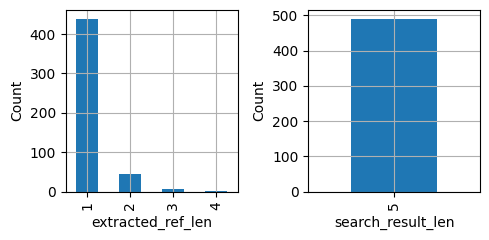

In [14]:
plot_lengths_by_type(df, "mrc_question")

- 출력된 결과를 보면 mrc_question 데이터의 유형인 경우 모든 데이터 491개의 검색 결과가 5개로 동일하며, 이중 439개는 답변시 1개의 문서를 인용하는 데이터
- 데이터가 매우 지엽적이어서 답변 시 다수의 문서를 인용하는 경우가 극히 드물다는 것을 보여줍니다.
